In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90


## 1. Conjunto de datos no linealmente separable: Círculos Concéntricos

En aprendizaje automático, existen problemas de clasificación que no pueden ser resueltos de manera óptima trazando una línea recta. El conjunto de datos de círculos concéntricos (`make_circles`) representa un caso típico: una clase se encuentra completamente contenida dentro de la otra. 

Ninguna frontera lineal podrá separar correctamente ambas categorías sin cometer un alto número de errores.


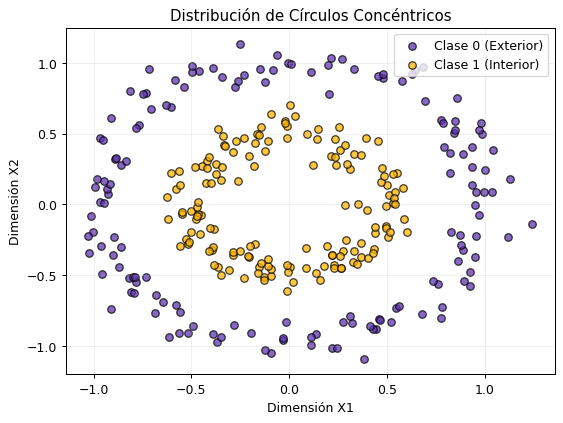

In [2]:
# Generamos círculos concéntricos
X, y = make_circles(n_samples=400, noise=0.08, factor=0.5, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X_tr[y_tr==0, 0], X_tr[y_tr==0, 1], c='#5E35B1', label='Clase 0 (Exterior)', alpha=0.75, edgecolor='k')
plt.scatter(X_tr[y_tr==1, 0], X_tr[y_tr==1, 1], c='#FFB300', label='Clase 1 (Interior)', alpha=0.75, edgecolor='k')
plt.xlabel('Dimensión X1')
plt.ylabel('Dimensión X2')
plt.title('Distribución de Círculos Concéntricos')
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.show()


In [3]:
def visualizar_limite(modelo, X, y, titulo):
    """Grafica la frontera de decisión aprendida por el clasificador en un plano bidimensional."""
    resolucion = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolucion), np.arange(y_min, y_max, resolucion))
    
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='#5E35B1', edgecolor='k', label='Clase 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='#FFB300', edgecolor='k', label='Clase 1')
    plt.title(titulo)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


## 2. Intento 1: Regresión Logística

Como modelo lineal, la regresión logística busca encontrar una recta de separación óptima. Al no poder doblar esta frontera, su desempeño en este conjunto de datos circular es severamente limitado, ya que clasifica la mitad de los círculos de manera errónea.


Exactitud de la Regresión Logística (Test): 0.430


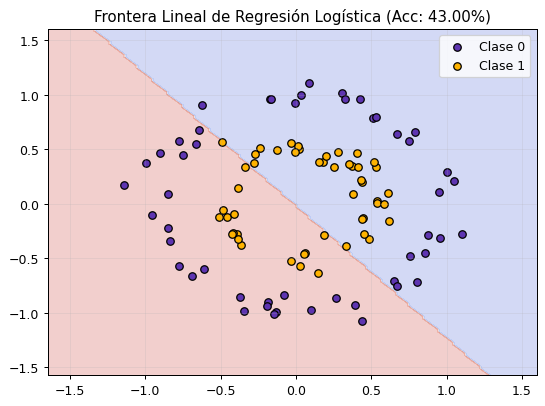

In [4]:
reg_logistica = LogisticRegression(random_state=42)
reg_logistica.fit(X_tr, y_tr)
exactitud_logreg = accuracy_score(y_te, reg_logistica.predict(X_te))

print(f'Exactitud de la Regresión Logística (Test): {exactitud_logreg:.3f}')
visualizar_limite(reg_logistica, X_te, y_te, f'Frontera Lineal de Regresión Logística (Acc: {exactitud_logreg:.2%})')


## 3. Intento 2: Árbol de Decisión

Los árboles de decisión no aprenden coeficientes continuos, sino que formulan preguntas sucesivas sobre las características:

```
¿Es la Dimensión X2 > -0.6?
├── Sí → ¿Es la Dimensión X1 > -0.5?
│   ├── Sí → ¿Es X1 < 0.5? → Clase 1 (Interior)
│   └── No  → Clase 0
└── No  → Clase 0
```

Al combinar múltiples condiciones paralelas a los ejes, el árbol de decisión dibuja una frontera poligonal en forma de "escalera" que puede encerrar y aislar la región central (Clase 1) con gran precisión.


Exactitud del Árbol de Decisión (Test): 0.980
Mejora con respecto a la Regresión Logística: +55.0 puntos porcentuales


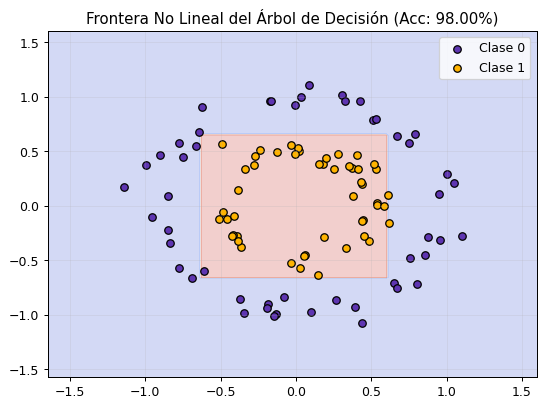

In [5]:
arbol_clasif = DecisionTreeClassifier(max_depth=5, random_state=42)
arbol_clasif.fit(X_tr, y_tr)
exactitud_arbol = accuracy_score(y_te, arbol_clasif.predict(X_te))

print(f'Exactitud del Árbol de Decisión (Test): {exactitud_arbol:.3f}')
print(f'Mejora con respecto a la Regresión Logística: +{(exactitud_arbol - exactitud_logreg)*100:.1f} puntos porcentuales')

visualizar_limite(arbol_clasif, X_te, y_te, f'Frontera No Lineal del Árbol de Decisión (Acc: {exactitud_arbol:.2%})')


Mejores parámetros encontrados: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Exactitud del Árbol de Decisión Optimizado: 0.980
Mejora final vs Regresión Logística: +55.0 puntos


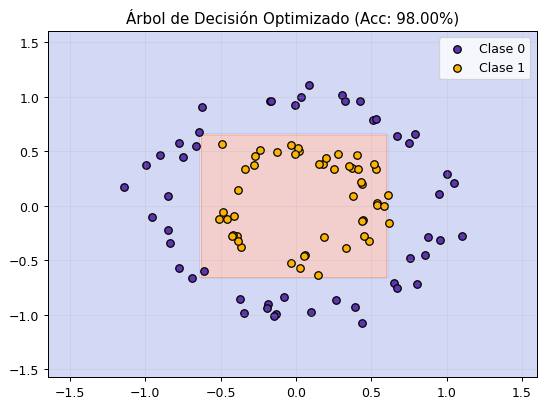

In [6]:
# Buscamos optimizar el árbol mediante una rejilla de hiperparámetros
espacio_parametros = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [1, 2, 4, 8],
    'min_samples_split': [2, 4, 8]
}

arbol_base = DecisionTreeClassifier(random_state=42)
busqueda_rejilla = GridSearchCV(estimator=arbol_base, param_grid=espacio_parametros, cv=5, scoring='accuracy', n_jobs=-1)
busqueda_rejilla.fit(X_tr, y_tr)

mejor_arbol = busqueda_rejilla.best_estimator_
exactitud_mejor_arbol = accuracy_score(y_te, mejor_arbol.predict(X_te))

print(f'Mejores parámetros encontrados: {busqueda_rejilla.best_params_}')
print(f'Exactitud del Árbol de Decisión Optimizado: {exactitud_mejor_arbol:.3f}')
print(f'Mejora final vs Regresión Logística: +{(exactitud_mejor_arbol - exactitud_logreg)*100:.1f} puntos')

visualizar_limite(mejor_arbol, X_te, y_te, f'Árbol de Decisión Optimizado (Acc: {exactitud_mejor_arbol:.2%})')


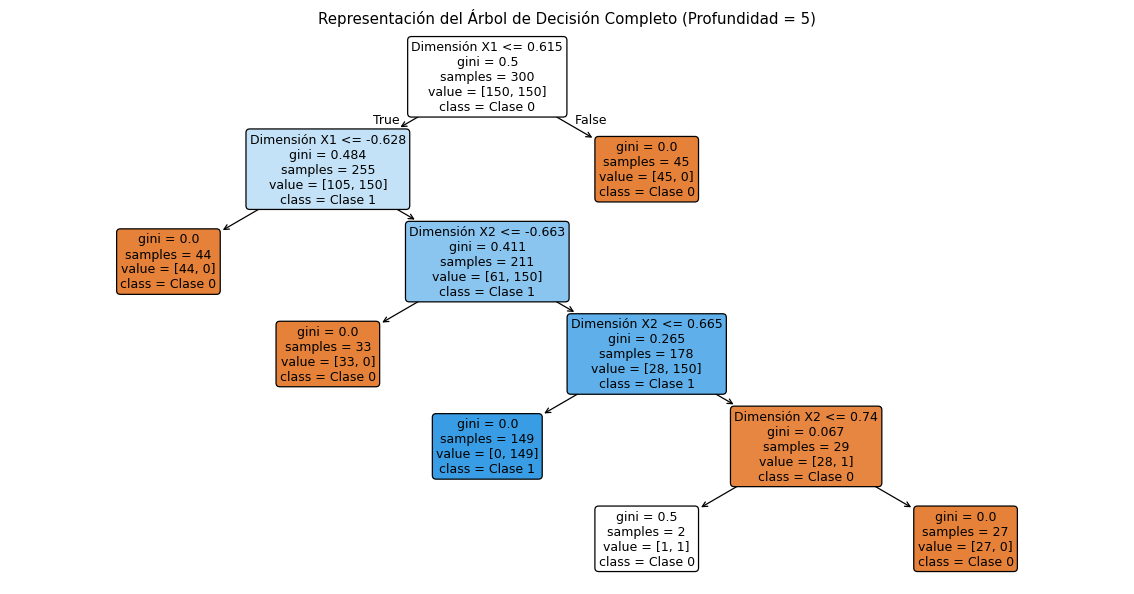

In [7]:
plt.figure(figsize=(16, 8))
plot_tree(
    arbol_clasif,
    filled=True,
    rounded=True,
    feature_names=['Dimensión X1', 'Dimensión X2'],
    class_names=['Clase 0', 'Clase 1'],
    fontsize=10
)
plt.title('Representación del Árbol de Decisión Completo (Profundidad = 5)')
plt.show()


# Interpretación de la Visualización del Árbol

El gráfico superior describe de forma explícita el camino lógico seguido por el clasificador. A continuación se desglosan los parámetros configurados en el bloque de código:

* **`filled=True`**: Colorea cada nodo de acuerdo con su clase mayoritaria. Un color de gran intensidad representa alta pureza (bajo valor de Gini), mientras que tonalidades tenues indican incertidumbre.
* **`rounded=True`**: Aplica un diseño estético de bordes redondeados a las cajas.
* **`feature_names`**: Sustituye los índices de entrada genéricos por los nombres descriptivos asignados a las dimensiones (`Dimensión X1`, `Dimensión X2`).
* **`class_names`**: Etiqueta el resultado predicho en cada ramificación para una lectura rápida del resultado final.

### Información contenida en cada caja:
1. **Regla de división (split rule)**: Umbral matemático evaluado para separar las muestras.
2. **Índice de Gini (o Entropía)**: Métrica de impureza del nodo.
3. **Samples**: Número de muestras de entrenamiento evaluadas en esa caja.
4. **Value**: Distribución de clases de las muestras en dicho nodo.
5. **Class**: Categoría asignada provisionalmente en esta rama.


## Conjuntos de datos estructurados para Bosques de Decisión
Los bosques de decisión son la mejor alternativa disponible cuando se trabaja con información tabular estructurada (filas y columnas ordenadas en un formato tipo hoja de cálculo, base de datos SQL o archivos CSV).

**Estadísticas de Equipos (Mundial 2026 - Clasificación de Candidatos):**

| Posesión Promedio (%) | Efectividad de Pases (%) | Goles Marcados | Candidato al Título (Etiqueta) |
| :--- | :--- | :--- | :--- |
| 63.5 | 88.2 | 8 | Candidato Fuerte |
| 42.1 | 68.5 | 3 | No Candidato |
| 56.4 | 81.3 | 5 | Candidato Medio |


A diferencia del aprendizaje profundo, los árboles de decisión son idóneos para datos estructurados porque **no requieren pasos complejos de ingeniería de características**:

* **Sin normalización**: No se ven afectados por las diferencias de escala entre variables.
* **Sin codificación one-hot**: Procesan características categóricas sin necesidad de expandir el espacio de entrada.
* **Robustez ante valores nulos**: Manejan datos perdidos de manera nativa sin requerir imputación manual.

*Nota*: Son algoritmos altamente eficientes en el uso de datos (sample efficient) y ejecutan la inferencia en pocos microsegundos dentro de cualquier CPU estándar.


## Estructura Jerárquica del Árbol de Decisión
Los modelos estructurados constan de una secuencia lógica de toma de decisiones dividida en nodos:

* **Raíz (Root)**: Nodo superior donde comienza la evaluación del conjunto.
* **Condición o división (split)**: Preguntas basadas en umbrales lógicos sobre las columnas.
* **Hojas (Leaf nodes)**: Terminales del árbol que devuelven la etiqueta o predicción final.

### Esquema del Árbol de Clasificación (Evaluación del Mundial)
* **Raíz**: `Goles Marcados >= 2.0`
    * **No** → **No Candidato** (Hoja)
    * **Sí** → Nodo Intermedio: `Tarjetas Rojas <= 1`
        * **Sí** → **Candidato Fuerte** (Hoja)
        * **No** → **Candidato Medio** (Hoja)


DIAGRAMA: Estructura del Árbol de Clasificación


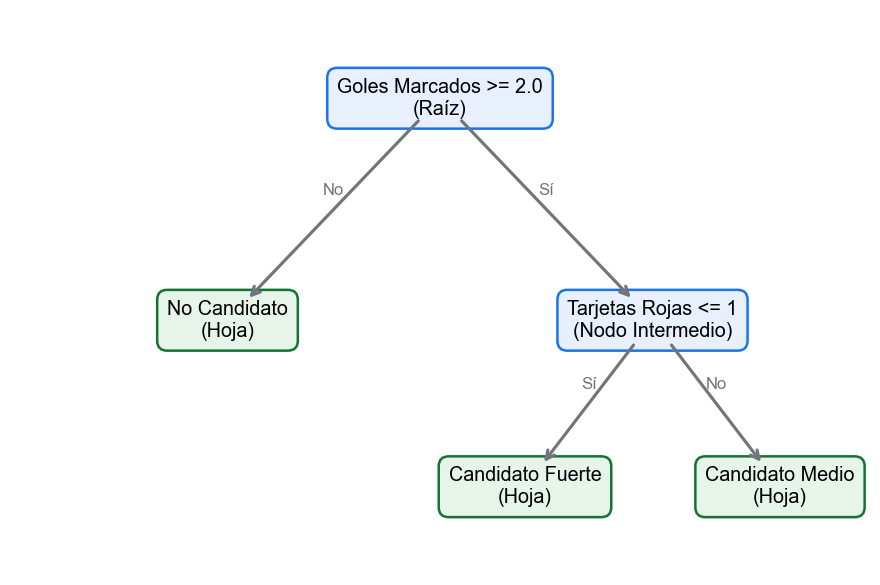


## Proceso de Inferencia
Para clasificar una nueva muestra, esta es guiada a través del árbol comenzando por la raíz. Dependiendo del resultado de cada condicional, desciende por la rama correspondiente hasta alcanzar una hoja. Los nodos atravesados forman la **ruta de inferencia**.

**Ejemplo de inferencia (Evaluación de Selección):**
Variables de entrada de un equipo:
* `Goles Marcados` = 2.4
* `Tarjetas Rojas` = 2

**Ruta lógica:**
1. ¿`Goles Marcados` >= 2.0? -> **Sí** (2.4 >= 2.0). Avanzamos al nodo intermedio.
2. ¿`Tarjetas Rojas` <= 1? -> **No** (2 > 1). Llegamos al nodo hoja.
* **Clasificación final:** Candidato Medio.


DIAGRAMA: Ruta de Inferencia Recorrida


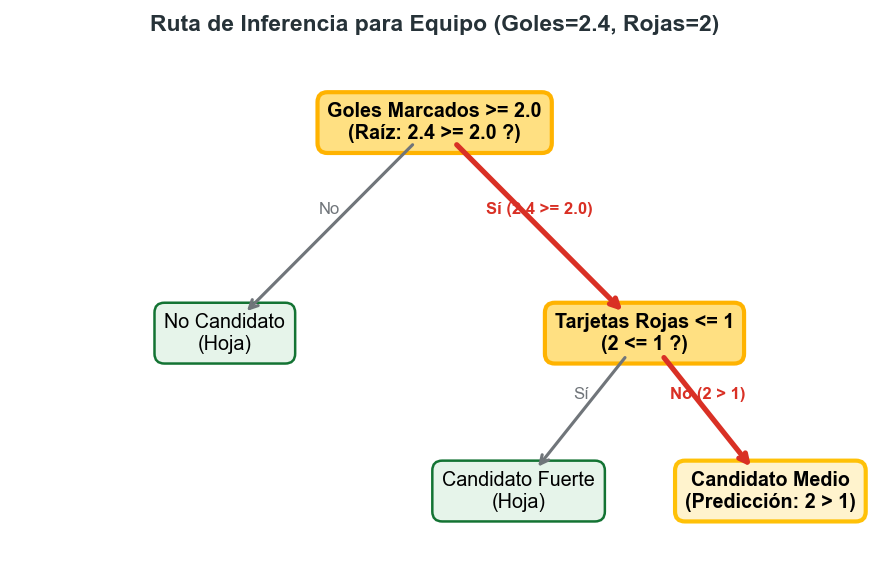


## Modelos de Regresión con Árboles
Además de clasificar datos en categorías discretas, los árboles pueden estimar valores continuos (regresión). En este caso, cada nodo hoja devuelve un número real correspondiente al promedio de los valores de entrenamiento en esa hoja.

**Ejemplo: Predicción de Puntos esperados en Fase de Grupos:**
* Raíz: ¿`Posesión` >= 55%?
    * **Sí** → Nodo Intermedio: ¿`Efectividad de Pases` >= 80%?
        * Sí → **Predicción: 7.5 Puntos**
        * No → **Predicción: 5.2 Puntos**
    * **No** → **Predicción: 3.1 Puntos**


DIAGRAMA: Árbol de Regresión de Puntos


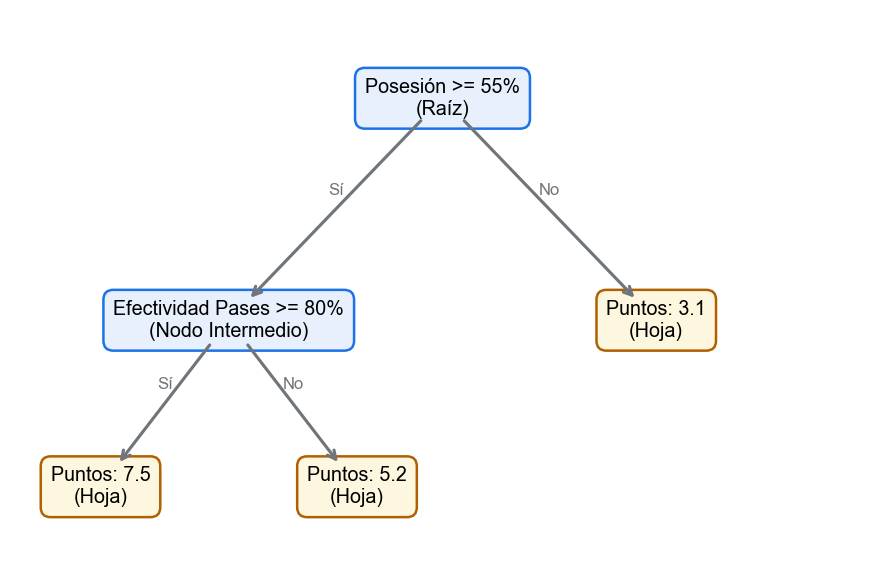


## Tipos de Condiciones en la Estructura: Alineadas a los ejes vs. Oblicuas

1. **Condiciones alineadas a los ejes (Axis-aligned)**: Evalúan una sola característica contra un umbral constante. Gráficamente, producen fronteras de decisión de forma ortogonal (líneas horizontales o verticales).
   * *Ejemplo*: `Posesión Promedio >= 55%`
   
2. **Condiciones oblicuas (Oblique)**: Evalúan una combinación lineal de múltiples variables. Permiten trazar líneas de separación diagonales en el plano de características.
   * *Ejemplo*: `Posesión Promedio + Efectividad de Pases >= 135%`


DIAGRAMA: División del Espacio de Características


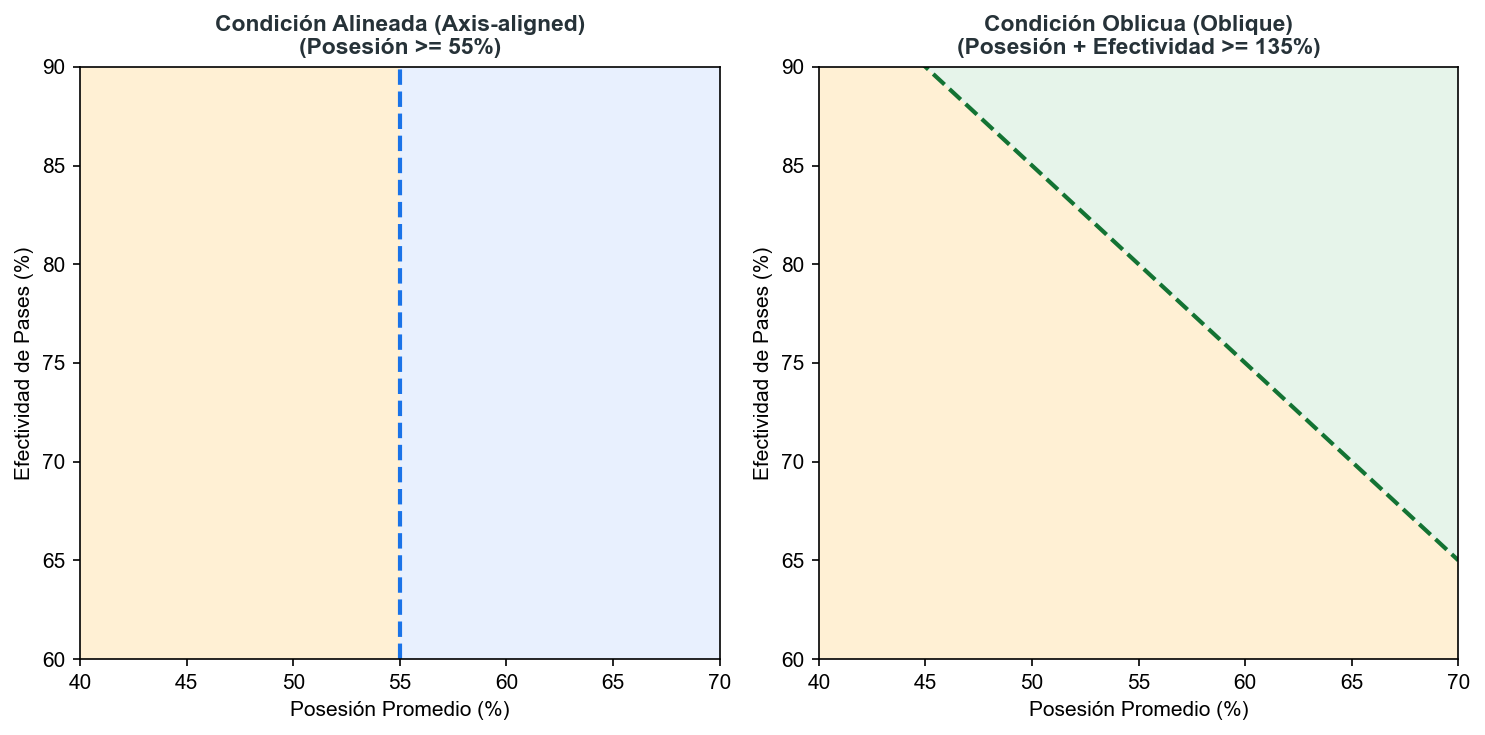


## Divisiones Binarias vs. No Binarias

* **Condición Binaria**: Divide el conjunto de muestras en dos posibles resultados (Verdadero o Falso). Su diseño simple reduce el sobreajuste y se utiliza como base en los algoritmos de conjuntos (Ensembles).
  * *Ejemplo*: `Goles Marcados >= 2.0`
* **Condición No Binaria (Multi-ruta)**: Divide las muestras en tres o más ramificaciones de manera simultánea. Permite clasificar directamente variables categóricas, pero es propensa al sobreajuste.
  * *Ejemplo*: `Grupo del Mundial` (Grupo A, Grupo B, etc.)


DIAGRAMA: Comparativa de Divisiones


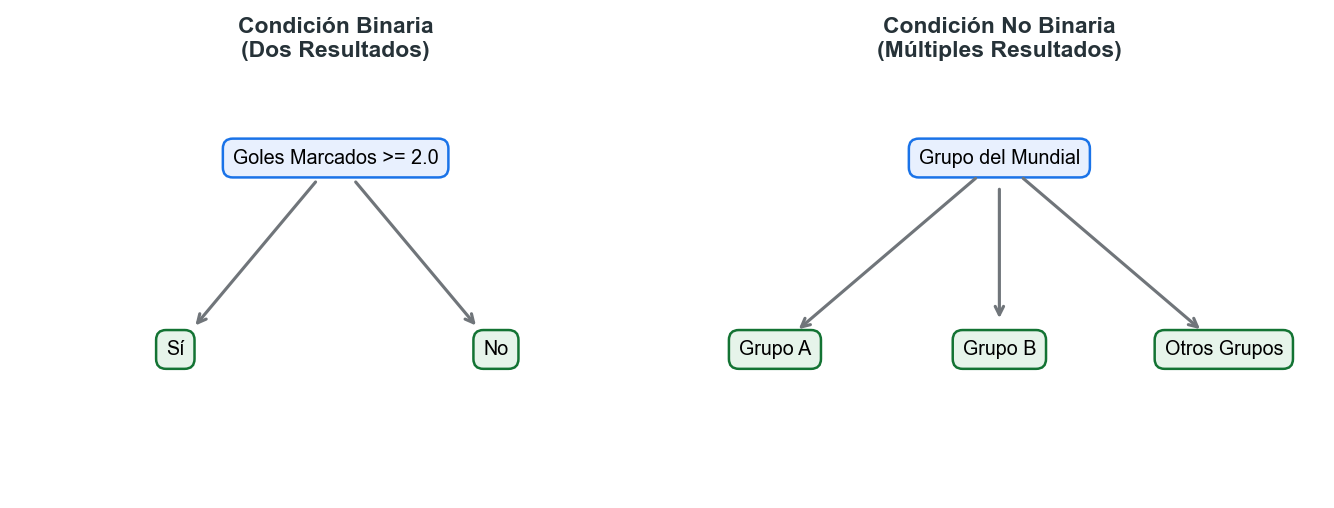


### Tabla de Tipos de Condiciones (Ejemplos del Mundial 2026)

| Nombre de la Condición | Estructura Matemática | Ejemplo de Selección |
| :--- | :--- | :--- |
| **Condición de umbral** | `feature > threshold` | `Goles Marcados >= 2.0` |
| **Condición de igualdad** | `feature == value` | `Confederacion == "CONMEBOL"` |
| **Condición de pertenencia** | `feature ∈ collection` | `Grupo ∈ {"Grupo A", "Grupo B"}` |
| **Condición oblicua** | `Σ (weight * feature) >= threshold` | `Posesion + Efectividad >= 135` |
| **Característica faltante** | `feature isMissing` | `Goles_En Contra isMissing` |
